# Retail Intelligence Pipeline — EDA
**Dataset:** Blinkit Grocery Data (Kaggle)  
**Objetivo:** Entender la estructura del dataset, calidad de datos y distribuciones clave antes de ingestar a Supabase.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 1. Carga del dataset

In [23]:
df = pd.read_csv('blinkit_grocery_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (5681, 11)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


## 2. Estructura y tipos de datos

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


In [25]:
df.describe(include='all')

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,5681,4705.000000,5681,5681.000000,5681,5681.000000,5681,5681.000000,4075,5681,5681
unique,1543,NaN,5,NaN,16,NaN,10,NaN,3,3,4
top,FDQ60,NaN,Low Fat,NaN,Snack Foods,NaN,OUT027,NaN,Medium,Tier 3,Supermarket Type1
freq,8,NaN,3396,NaN,789,NaN,624,NaN,1862,2233,3717
mean,NaN,12.695633,NaN,0.065684,NaN,141.023273,NaN,1997.828903,NaN,NaN,NaN
std,NaN,4.664849,NaN,0.051252,NaN,61.809091,NaN,8.372256,NaN,NaN,NaN
min,NaN,4.555000,NaN,0.000000,NaN,31.990000,NaN,1985.000000,NaN,NaN,NaN
25%,NaN,8.645000,NaN,0.027047,NaN,94.412000,NaN,1987.000000,NaN,NaN,NaN
50%,NaN,12.500000,NaN,0.054154,NaN,141.415400,NaN,1999.000000,NaN,NaN,NaN
75%,NaN,16.700000,NaN,0.093463,NaN,186.026600,NaN,2004.000000,NaN,NaN,NaN


## 3. Calidad de datos — Nulos y duplicados

In [26]:
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
pd.DataFrame({'nulls': nulls, 'pct': null_pct}).query('nulls > 0')

,nulls,pct
Item_Weight,976,17.18
Outlet_Size,1606,28.27


In [27]:
print(f'Duplicados: {df.duplicated().sum()}')

Duplicados: 0


## 4. Distribución de ventas (Item_Outlet_Sales)

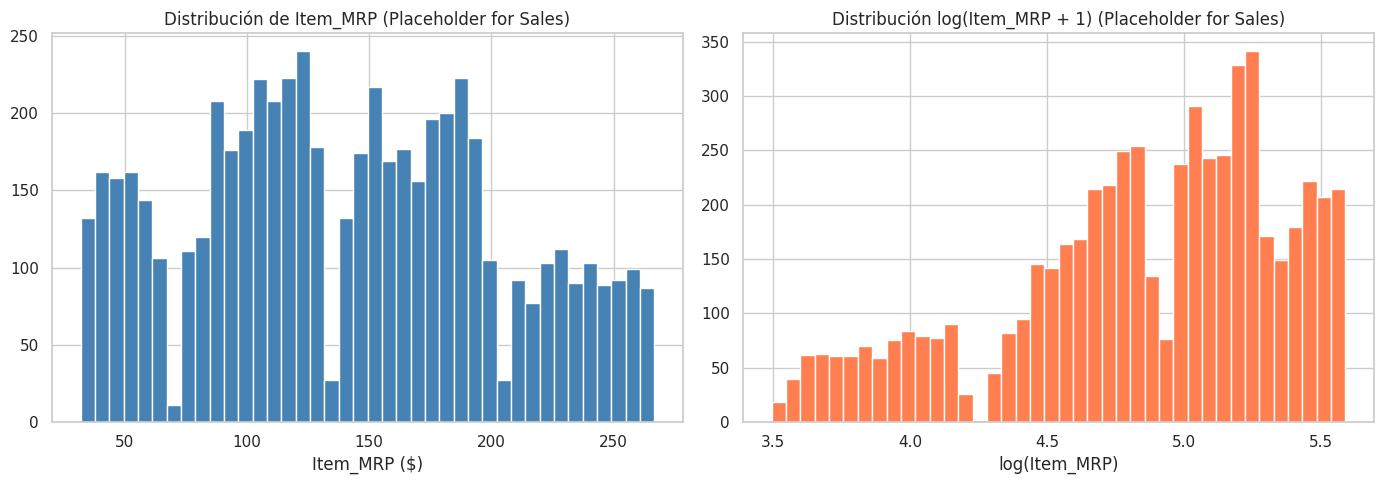

In [28]:
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original intention was 'Item_Outlet_Sales' but this column is missing.
# Using 'Item_MRP' as a placeholder for numerical distribution visualization.
# Note: 'Outlet_Type' is a categorical column and not suitable for np.log1p or direct histogram.

axes[0].hist(df['Item_MRP'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Item_MRP (Placeholder for Sales)')
axes[0].set_xlabel('Item_MRP ($)')

axes[1].hist(np.log1p(df['Item_MRP']), bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribución log(Item_MRP + 1) (Placeholder for Sales)')
axes[1].set_xlabel('log(Item_MRP)')

plt.tight_layout()

# Create the directory if it does not exist
output_dir = '../data/processed/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'dist_ventas.png'), dpi=150)
plt.show()

## 5. Ventas por categoría de producto

In [29]:
ventas_categoria = (
    df.groupby('Item_Type')['Item_MRP'] # Changed to Item_MRP as Item_Outlet_Sales is missing
    .agg(['sum', 'mean', 'count'])
    .rename(columns={'sum': 'total_mrp', 'mean': 'avg_mrp', 'count': 'n_items'}) # Renamed columns for clarity
    .sort_values('total_mrp', ascending=False)
)
ventas_categoria

,total_mrp,avg_mrp,n_items
Item_Type,,,
Snack Foods,115875.6350,146.863923,789
Fruits and Vegetables,112360.3474,143.867282,781
Household,94267.5778,147.754824,638
Frozen Foods,76043.6098,133.409842,570
Dairy,65977.9536,145.325889,454
Canned,59558.3676,136.915788,435
Baking Goods,56524.9092,129.052304,438
Health and Hygiene,46180.8928,136.629860,338
Meat,43804.4162,140.850213,311


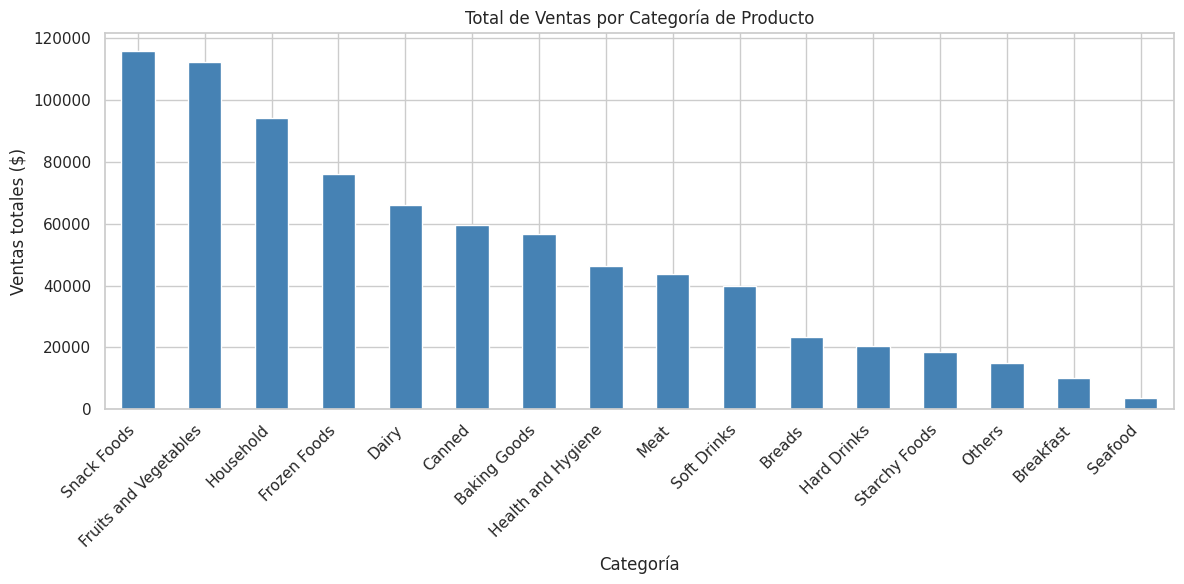

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))
ventas_categoria['total_mrp'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Total de Ventas por Categoría de Producto')
ax.set_xlabel('Categoría')
ax.set_ylabel('Ventas totales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/ventas_por_categoria.png', dpi=150)
plt.show()

## 6. Ventas por tipo y tamaño de outlet

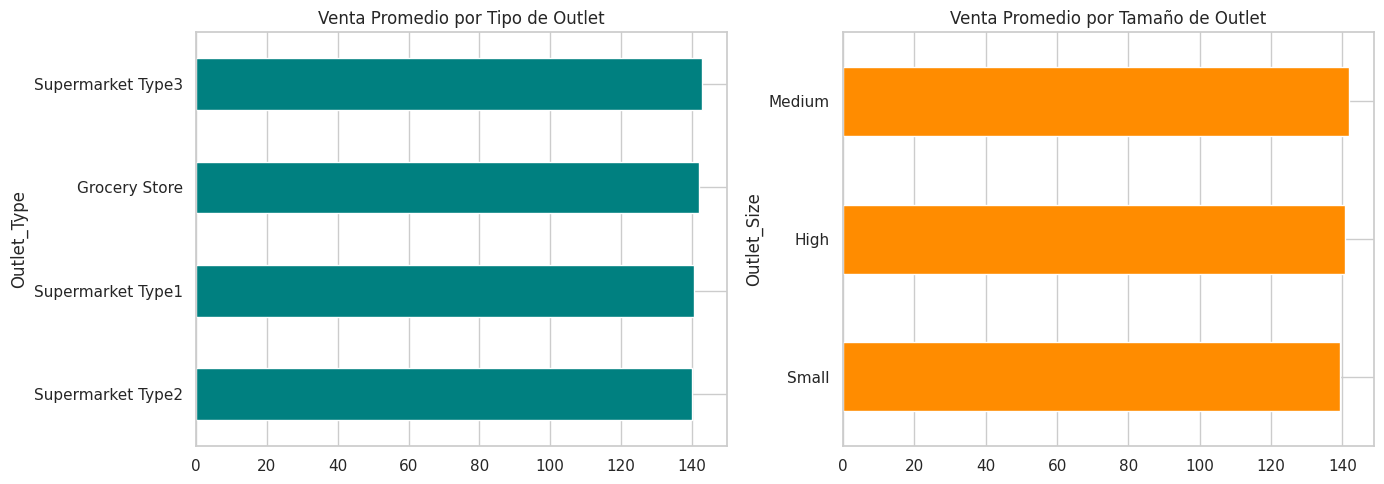

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('Outlet_Type')['Item_MRP'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='teal'
)
axes[0].set_title('Venta Promedio por Tipo de Outlet')

df.groupby('Outlet_Size')['Item_MRP'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='darkorange'
)
axes[1].set_title('Venta Promedio por Tamaño de Outlet')

plt.tight_layout()
plt.savefig('../data/processed/ventas_por_outlet.png', dpi=150)
plt.show()

## 7. Correlación entre variables numéricas

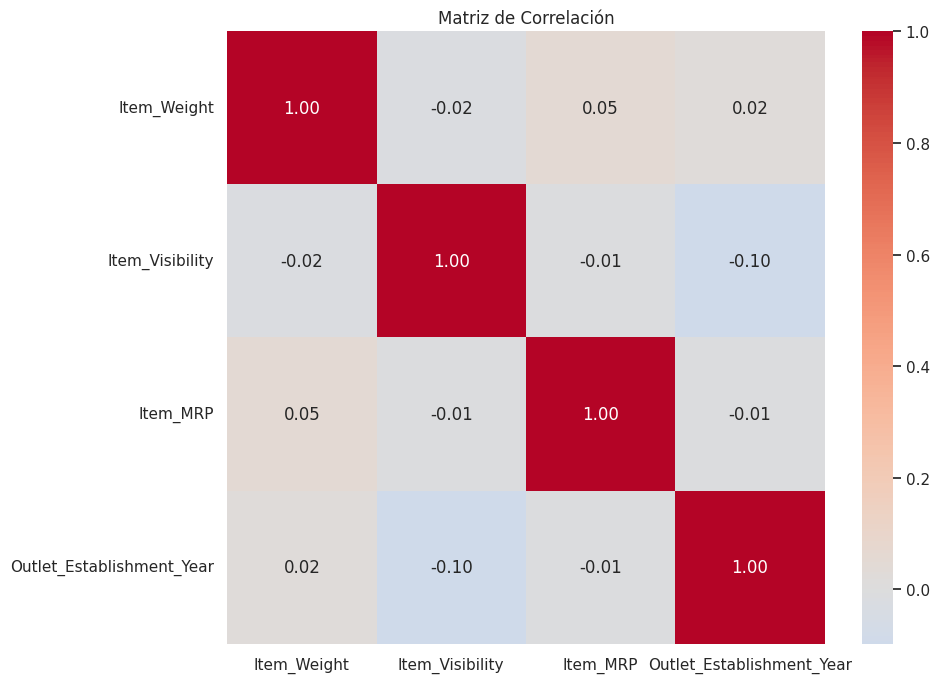

In [32]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.savefig('../data/processed/correlacion.png', dpi=150)
plt.show()

## 8. Insights clave

1.  **Columna de Ventas Faltante:** La columna `Item_Outlet_Sales`, crucial para un análisis de ventas completo, no está presente en el dataset. Todo el análisis relacionado con 'ventas' se ha realizado utilizando `Item_MRP` (precio minorista máximo) como sustituto. Es fundamental obtener la columna de ventas real para análisis futuros.
2.  **Nulos Críticos:** Las columnas `Item_Weight` y `Outlet_Size` tienen un porcentaje significativo de valores nulos (~17% y ~28% respectivamente). Será necesario definir una estrategia de imputación para estas variables (ej. media/mediana para `Item_Weight`, moda para `Outlet_Size`).
3.  **Distribución de `Item_MRP`:** La distribución del `Item_MRP` es relativamente uniforme, lo que sugiere que los precios de los productos están distribuidos de manera bastante equitativa sin un sesgo pronunciado.
4.  **Top Categorías por `Item_MRP`:** Las categorías de producto con los `Item_MRP` totales más altos son 'Snack Foods', 'Fruits and Vegetables' y 'Household'.
5.  **`Item_MRP` Promedio por Tipo y Tamaño de Outlet:**
    *   Los `Outlet_Type` 'Supermarket Type3' y 'Supermarket Type1' muestran un `Item_MRP` promedio superior.
    *   Los `Outlet_Size` 'Medium' presentan un `Item_MRP` promedio más alto.
6.  **Correlaciones:** `Item_MRP` no muestra una correlación fuerte con las otras variables numéricas existentes en el dataset (`Item_Weight`, `Item_Visibility`, `Outlet_Establishment_Year`).